### Import Dependencies

In [1]:
from pydantic import BaseModel, Field

from qdrant_client import QdrantClient
from qdrant_client.models import Prefetch, Filter, FieldCondition, MatchText, FusionQuery, Document

from langsmith import traceable, get_current_run_tree, Client

from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

from jinja2 import Template
from typing import Literal, Dict, Any, Annotated, List, Optional, Sequence
from IPython.display import Image, display
from operator import add

from google import genai
from google.genai import types

from dotenv import load_dotenv

import os

2026-07-29 17:57:12.656291228 [W:onnxruntime:Default, device_discovery.cc:164 DiscoverDevicesForPlatform] GPU device discovery failed: device_discovery.cc:89 ReadFileContents Failed to open file: "/sys/class/drm/card0/device/vendor"


In [2]:
load_dotenv()

GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")
if not GOOGLE_API_KEY:
    raise ValueError("GOOGLE_API_KEY not found in .env file!")

# Native google-genai client -> used for the RAG pipeline itself
# (embeddings + answer generation)
gemini_client = genai.Client(api_key=GOOGLE_API_KEY)

# LangSmith client -> used to pull the evaluation dataset (optional, only needed if you run evals)
ls_client = Client()

In [3]:
qdrant_client = QdrantClient(url="http://localhost:6333")

/tmp/ipykernel_144987/3504550968.py:1: UserWarning: Qdrant client version 1.16.2 is incompatible with server version 1.18.2. Major versions should match and minor version difference must not exceed 1. Set check_compatibility=False to skip version check.
  qdrant_client = QdrantClient(url="http://localhost:6333")


#### Pre-flight check

This confirms the collection actually exists before we try to query it. If you get a `ValueError` here, it means the ingestion/indexing notebook that creates and populates `Amazon-items-collection-01-hybrid-search` has not been run yet against this Qdrant instance — run that notebook first, then re-run this cell.

In [4]:
COLLECTION_NAME = "Amazon-items-collection-01-hybrid-search"

existing_collections = [c.name for c in qdrant_client.get_collections().collections]

if COLLECTION_NAME not in existing_collections:
    raise ValueError(
        f"Collection '{COLLECTION_NAME}' does not exist in this Qdrant instance.\n"
        f"Available collections: {existing_collections}\n\n"
        "This means the data-ingestion notebook (the one that creates the collection and "
        "upserts the Amazon product embeddings + BM25 index) has not been run yet, or you are "
        "pointing at a different Qdrant instance than the one it was indexed into.\n"
        "Run the ingestion notebook first, then re-run this cell."
    )

print(f"OK: '{COLLECTION_NAME}' found. Existing collections: {existing_collections}")

OK: 'Amazon-items-collection-01-hybrid-search' found. Existing collections: ['Amazon-items-collection-01', 'Amazon-items-collection-01-hybrid-search', 'Amazon-items-collection-02', 'Amazon-items-collection-03']


In [5]:
def get_embedding(text, model="gemini-embedding-001"):
    response = gemini_client.models.embed_content(
        model=model,
        contents=text,
    )
    return response.embeddings[0].values

In [6]:
def retrieve_data(query, qdrant_client, k=5):

    query_embedding = get_embedding(query)

    results = qdrant_client.query_points(
        collection_name=COLLECTION_NAME,
        prefetch=[
            Prefetch(
                query=query_embedding,
                using="gemini-embedding-001",
                limit=20
            ),
            Prefetch(
                query=Document(
                    text=query,
                    model="qdrant/bm25"
                ),
                using="bm25",
                limit=20
            )
        ],
        query=FusionQuery(fusion="rrf"),
        limit=k,
    )

    retrieved_context_ids = []
    retrieved_context = []
    similarity_scores = []
    retrieved_context_ratings = []

    for result in results.points:
        retrieved_context_ids.append(result.payload["parent_asin"])
        retrieved_context.append(result.payload["description"])
        retrieved_context_ratings.append(result.payload["average_rating"])
        similarity_scores.append(result.score)

    return {
        "retrieved_context_ids": retrieved_context_ids,
        "retrieved_context": retrieved_context,
        "retrieved_context_ratings": retrieved_context_ratings,
        "similarity_scores": similarity_scores,
    }

In [7]:
query = "Can I get a tablet?"

In [8]:
answer = retrieve_data(query, qdrant_client, k=10)

In [9]:
answer

{'retrieved_context_ids': ['B0B8NVNQKX',
  'B0B4WCNWF3',
  'B0BN7WWH63',
  'B0BL12DTJ5',
  'B0C3LNX75K',
  'B0BL2CZSHT',
  'B0BFGXRMJN',
  'B0BCQ8RJG7',
  'B0B6ZZH83Y',
  'B0B5517LRN'],
 'retrieved_context': ['COOPERS 7 inch Kids Tablet Android 11 Tablet for Kids, 2GB RAM + 32GB ROM Toddler Tablet PC for Children, IPS Touch Screen, Dual Camera, Dual Speaker, WiFi Computer Tablet, Light Blue ✿【Good Kids tablet】This 7 inch tablet for kids with silm body and lightweight, it is easy to hold by children. Also the special design can protect the tablet well when dropping. ✿【Parental Control】Toddlers Tablet with parent mode can add or block apps. Set screen time limits. This tablet come with iwawa app. kids can get access to fun and educational games and videos. ✿【Powerful Tablets】Equipmented with quad core CPU, Android 11.0 System, 32GB Big Storage, 1024*600 IPS Screen offer a clear view. Runs Kinds of apps and game for kids smoothly. ✿【Long Lasting】Tablet for kids built with large capacity b

### Multi-Intent Questions

In [10]:
query = "Can I get a tablet for my kid, a watch for me and a laptop for my wife?"

In [11]:
answer = retrieve_data(query, qdrant_client, k=10)

In [12]:
answer

{'retrieved_context_ids': ['B0BL2CZSHT',
  'B0B7XC9VL4',
  'B0BRXZDBXZ',
  'B0B8NVNQKX',
  'B0C142QS8X',
  'B0BCQ8RJG7',
  'B09XQGN52P',
  'B09Q8FLNDR',
  'B0C3XYD574',
  'B0BQYHF2GG'],
 'retrieved_context': ['All-New 10and 10 Plus 2021 Tablet Case for Kids, Ubearkk Adult & Kids Friendly Light Weight Shock Proof Kid-Proof Back Cover Compatible 101h Generation 2021 Model Compatibility- Designed for All-New ＨＤ 10 & ＨＤ 10 Plus Tablet & ＨＤ 10 Kids Pro Tablet Latest model(Only compatible with 11th Generation, 2021 Release). NOT Fit for other generations. Kids-proof Case-Made with dense heavy duty EVA foam material can withstand considerable wear and tear and provide extreme shock protection. Super light weight and durable hazard free safe material perfect for kids and grownups alike. Built-in Kickstand - Designed with a foldable kick-stand on the back of the case, allows you to set up multiple angles and gives you the hands-free convenience when watching videos and movies. Precise cutouts- 

#### Simple Query Expansion (no graph yet)

In [13]:
class QueryExpandResponse(BaseModel):
   statements: List[str]

In [14]:
def query_expand_node(query) -> dict:

   prompt_template = """You are part of a shopping assistant that can answer questions about products in stock.

Instructions:
- You will be given a question and you need to expand it into a list of statements that can be used in contextual search to retrieve relevant products.
- The statements should not overlap in context.

<Question>
{{ query }}
</Question>
"""

   template = Template(prompt_template)

   prompt = template.render(
      query=query
   )

   response = gemini_client.models.generate_content(
        model="gemini-3.5-flash",
        contents=prompt,
        config=types.GenerateContentConfig(
            temperature=0.5,
            response_mime_type="application/json",
            response_schema=QueryExpandResponse,
        ),
   )

   parsed: QueryExpandResponse = response.parsed

   return {
      "queries": parsed.statements
   }

In [15]:
answer = query_expand_node(query)

In [16]:
answer

{'queries': ['A tablet designed for children and kids.',
  'A wristwatch or smartwatch for an adult.',
  'A laptop computer suitable for a woman.']}

### LangGraph

#### Query Expansion (Sequential Execution)

In [16]:
class State(BaseModel):
    expanded_query: List[str] = []
    retrieved_context: Annotated[List[str], add] = []
    initial_query: str = ""
    answer: str = "" 

#### Query Expansion / Rewriting Node

In [17]:
class QueryExpandResponse(BaseModel):
   expanded_query: List[str]

In [18]:
@traceable(
    name="query_expand_node",
    run_type="llm",
    metadata={"ls_provider": "google", "ls_model_name": "gemini-3.5-flash"}
)
def query_expand_node(state: State) -> dict:

   prompt_template = """You are part of a shopping assistant that can answer questions about products in stock.

Instructions:
- You will be given a question and you need to expand it into a list of statements that can be used in contextual search to retrieve relevant products.
- The statements should not overlap in context.
- Be as concise as possible, do not make up synonims for statements, one statement per piece of context.

<Question>
{{ query }}
</Question>
"""

   template = Template(prompt_template)

   prompt = template.render(
      query=state.initial_query
   )

   response = gemini_client.models.generate_content(
        model="gemini-3.5-flash",
        contents=prompt,
        config=types.GenerateContentConfig(
            temperature=0.5,
            response_mime_type="application/json",
            response_schema=QueryExpandResponse,
        ),
   )

   parsed: QueryExpandResponse = response.parsed

   return {
      "expanded_query": parsed.expanded_query
   }

#### Retriever Node

In [19]:
@traceable(
    name="embed_query",
    run_type="embedding",
    metadata={"ls_provider": "google", "ls_model_name": "gemini-embedding-001"}
)
def get_embedding(text, model="gemini-embedding-001"):
    response = gemini_client.models.embed_content(
        model=model,
        contents=text,
    )
    return response.embeddings[0].values


# @traceable(
#     name="retrieve_top_n",
#     run_type="retriever"
# )
# def retrieve_data(query, k=5):

#     query_embedding = get_embedding(query)

#     results = qdrant_client.query_points(
#         collection_name=COLLECTION_NAME,
#         prefetch=[
#             Prefetch(
#                 query=query_embedding,
#                 using="gemini-embedding-001",
#                 limit=20
#             ),
#             Prefetch(
#                 query=Document(
#                     text=query,
#                     model="qdrant/bm25"
#                 ),
#                 using="bm25",
#                 limit=20
#             )
#         ],
#         query=FusionQuery(fusion="rrf"),
#         limit=k,
#     )

#     retrieved_context_ids = []
#     retrieved_context = []
#     similarity_scores = []
#     retrieved_context_ratings = []

#     for result in results.points:
#         retrieved_context_ids.append(result.payload["parent_asin"])
#         retrieved_context.append(result.payload["description"])
#         retrieved_context_ratings.append(result.payload["average_rating"])
#         similarity_scores.append(result.score)

#     formatted_context = ""

#     for id, chunk, rating in zip(retrieved_context_ids, retrieved_context, retrieved_context_ratings):
#         formatted_context += f"- ID: {id}, rating: {rating}, description: {chunk}\n"

#     return formatted_context





@traceable(
    name="retrieve_top_n",
    run_type="retriever"
)
def retrieve_node(state: dict) -> dict:
    
    # 1. Access the dictionary payload sent by the Send() API
    current_query = state["query"]
    k_limit = state["k"]

    # 2. Generate the dense embedding
    query_embedding = get_embedding(current_query)

    # 3. Perform Hybrid Search
    results = qdrant_client.query_points(
        collection_name=COLLECTION_NAME,
        prefetch=[
            Prefetch(
                query=query_embedding,
                using="gemini-embedding-001",
                limit=20
            ),
            Prefetch(
                query=Document(
                    text=current_query,  # Use the extracted string variable
                    model="qdrant/bm25"
                ),
                using="bm25",
                limit=20
            )
        ],
        query=FusionQuery(fusion="rrf"),
        limit=k_limit, # Use the extracted limit variable
    )

    retrieved_context_ids = []
    retrieved_context = []
    similarity_scores = []
    retrieved_context_ratings = []

    for result in results.points:
        retrieved_context_ids.append(result.payload["parent_asin"])
        retrieved_context.append(result.payload["description"])
        retrieved_context_ratings.append(result.payload["average_rating"])
        similarity_scores.append(result.score)

    formatted_context = ""

    for id, chunk, rating in zip(retrieved_context_ids, retrieved_context, retrieved_context_ratings):
        formatted_context += f"- ID: {id}, rating: {rating}, description: {chunk}\n"

    # The result is appended to the main State's `retrieved_context` list by LangGraph
    return {
        "retrieved_context": [formatted_context]
    }




# @traceable(
#     name="retriever_node",
#     run_type="retriever"
# )
# def retriever_node(state: State) -> dict:

#     retrieved_context = []

#     for query in state.expanded_query:
#         retrieved_context.append(retrieve_data(query, k=5))

#     return {
#         "retrieved_context": retrieved_context
#     }


@traceable(
    name="retriever_node",
    run_type="retriever"
)
def retriever_node(state: State) -> dict:

    retrieved_context = []

    for query in state.expanded_query:
        # FIX: We must pass qdrant_client=qdrant_client here!
        retrieved_context.append(retrieve_data(query, qdrant_client=qdrant_client, k=5))

    return {
        "retrieved_context": retrieved_context
    }


#### Aggregator Node

In [20]:
class AggregatorResponse(BaseModel):
    answer: str = Field(description="Answer to the question.")

In [21]:
@traceable(
    name="aggregator_node",
    run_type="llm",
    metadata={"ls_provider": "google", "ls_model_name": "gemini-3.5-flash"}
)
def aggregator_node(state: State) -> dict:

   preprocessed_context = "\n".join(state.retrieved_context)

   prompt_template = """You are a shopping assistant that can answer questions about the products in stock.

You will be given a question and a list of context.

Instructions:
- You need to answer the question based on the provided context only.
- Never use word context and refer to it as the available products.
- The answer to the question should contain detailed information about the product and returned with detailed specification in bullet points.

Context:
{{ preprocessed_context }}

Question:
{{ question }}
"""

   template = Template(prompt_template)

   prompt = template.render(
      preprocessed_context=preprocessed_context,
      question=state.initial_query
   )

   response = gemini_client.models.generate_content(
        model="gemini-3.5-flash",
        contents=prompt,
        config=types.GenerateContentConfig(
            temperature=0.5,
            response_mime_type="application/json",
            response_schema=AggregatorResponse,
        ),
   )

   parsed: AggregatorResponse = response.parsed

   return {
      "answer": parsed.answer
   }

In [22]:
workflow = StateGraph(State)

workflow.add_node("query_expand_node", query_expand_node)
workflow.add_node("retriever_node", retriever_node)
workflow.add_node("aggregator_node", aggregator_node)

workflow.add_edge(START, "query_expand_node")
workflow.add_edge("query_expand_node", "retriever_node")
workflow.add_edge("retriever_node", "aggregator_node")
workflow.add_edge("aggregator_node", END)

graph = workflow.compile()

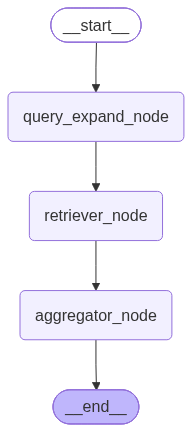

In [23]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [24]:
query = "Can I get a tablet for my kid, a watch for me and a laptop for my wife?"
initial_state = {
    "initial_query": query,
}

In [26]:
result = graph.invoke(initial_state)

TypeError: retrieve_data() missing 1 required positional argument: 'qdrant_client'

In [ ]:
result

{'expanded_query': ['kids tablet with parental controls and durable design',
  'smartwatch or wrist watch for adults',
  'lightweight laptop for everyday use and work'],
 'retrieved_context': ['- ID: B0C3XYD574, rating: 4.4, description: ROWT Tablet for Kids 10 inch Kids Tablet 2GB RAM 32GB ROM Android 11 6000mAh Wi-Fi, Bluetooth, Kid-Proof Case(Blue) 【Kids\' Safety & Parental Controls】Looking for a safe tablet that\'s easy for your kids to use? This 10-inch tablet for kids is GMS-certified, has password protection, a content filter, and a one-button lock screen, making it easier for parents to keep an eye on their kids activities and learning. 【Creative Educational Content】Our kids tablet provides access to a range of age-appropriate creative kids content such as drawing, educational games, eBooks, learning videos, math tools, and much more! Learning through play is best for kids to understand the world. 【Powerful Configuration & Full Access to Google】This Android 11 kids tablet has a

In [49]:
print(result["answer"])

Yes, you can find all of these items among the available products. Here are the recommended options:

1. For your kid: ROWT 10-inch Kids Tablet (ID: B0C3XYD574)
- Screen: 10.1-inch HD 1280x800 IPS touchscreen with eye protection to reduce blue light and glare.
- Performance: Equipped with Android 11, 1.6 GHz Quad-Core processor, 2GB RAM, and 32GB ROM.
- Safety: GMS-certified with parental controls including password protection, content filters, and a one-button lock screen.
- Battery: Large 6000mAh capacity.
- Case: Includes a durable blue kid-proof protective case with a built-in stand.

2. For you: Smart Watch for Men & Women (ID: B0BNPVBZPG)
- Communication: Directly make or answer calls and view text notifications on the wrist.
- Health Tracking: Monitored heart rate tracking and scientific sleep analysis (deep and light sleep).
- Fitness: Supports over 20 sports modes (running, cycling, yoga, etc.) and tracks steps, calories, and distance.
- Battery & Waterproofing: Waterproof des

#### Query Expansion (Parallel Execution)

In [50]:
class State(BaseModel):
    expanded_query: List[str] = []
    retrieved_context: Annotated[List[str], add] = []
    initial_query: str = ""
    answer: str = ""
    query: str = ""
    k: int = 10

#### Query Expansion / Rewriting Node

In [51]:
class QueryExpandResponse(BaseModel):
   expanded_query: List[str]

In [52]:
@traceable(
    name="query_expand_node",
    run_type="llm",
    metadata={"ls_provider": "google", "ls_model_name": "gemini-3.5-flash"}
)
def query_expand_node(state: State) -> dict:

   prompt_template = """You are part of a shopping assistant that can answer questions about products in stock.

Instructions:
- You will be given a question and you need to expand it into a list of statements that can be used in contextual search to retrieve relevant products.
- The statements should not overlap in context.
- The answer to the question should contain detailed information about the product and returned with detailed specification in bullet points.

<Question>
{{ query }}
</Question>
"""

   template = Template(prompt_template)

   prompt = template.render(
      query=state.initial_query
   )

   response = gemini_client.models.generate_content(
        model="gemini-3.5-flash",
        contents=prompt,
        config=types.GenerateContentConfig(
            temperature=0.5,
            response_mime_type="application/json",
            response_schema=QueryExpandResponse,
        ),
   )

   parsed: QueryExpandResponse = response.parsed

   return {
      "expanded_query": parsed.expanded_query
   }

In [53]:
def query_expand_conditional_edges(state: State):

    send_messages = []

    for query in state.expanded_query:
        send_messages.append(
            Send(
                "retrieve_node",
                {
                    "query": query,
                    "k": 10
                }
            )
        )

    return send_messages

#### Retriever Node

In [54]:
@traceable(
    name="embed_query",
    run_type="embedding",
    metadata={"ls_provider": "google", "ls_model_name": "gemini-embedding-001"}
)
def get_embedding(text, model="gemini-embedding-001"):
    response = gemini_client.models.embed_content(
        model=model,
        contents=text,
    )
    return response.embeddings[0].values


@traceable(
    name="retrieve_top_n",
    run_type="retriever"
)
def retrieve_node(state: State) -> dict:

    # FIX: `state` is a Pydantic BaseModel, not a dict -> use attribute access (state.query),
    # not subscript access (state["query"]). The BM25 Document must also use state.query,
    # not a bare `query` variable (which was never defined in this scope in the original code).
    query_embedding = get_embedding(state.query)

    results = qdrant_client.query_points(
        collection_name=COLLECTION_NAME,
        prefetch=[
            Prefetch(
                query=query_embedding,
                using="gemini-embedding-001",
                limit=20
            ),
            Prefetch(
                query=Document(
                    text=state.query,
                    model="qdrant/bm25"
                ),
                using="bm25",
                limit=20
            )
        ],
        query=FusionQuery(fusion="rrf"),
        limit=state.k,
    )

    retrieved_context_ids = []
    retrieved_context = []
    similarity_scores = []
    retrieved_context_ratings = []

    for result in results.points:
        retrieved_context_ids.append(result.payload["parent_asin"])
        retrieved_context.append(result.payload["description"])
        retrieved_context_ratings.append(result.payload["average_rating"])
        similarity_scores.append(result.score)

    formatted_context = ""

    for id, chunk, rating in zip(retrieved_context_ids, retrieved_context, retrieved_context_ratings):
        formatted_context += f"- ID: {id}, rating: {rating}, description: {chunk}\n"

    return {
        "retrieved_context": [formatted_context]
    }

#### Aggregator Node

In [55]:
class AggregatorResponse(BaseModel):
    answer: str = Field(description="Answer to the question.")

In [56]:
@traceable(
    name="aggregator_node",
    run_type="llm",
    metadata={"ls_provider": "google", "ls_model_name": "gemini-3.5-flash"}
)
def aggregator_node(state: State) -> dict:

   preprocessed_context = "\n".join(state.retrieved_context)

   prompt_template = """You are a shopping assistant that can answer questions about the products in stock.

You will be given a question and a list of context.

Instructions:
- You need to answer the question based on the provided context only.
- Never use word context and refer to it as the available products.
- The answer to the question should contain detailed information about the product and returned with detailed specification in bullet points.

Context:
{{ preprocessed_context }}

Question:
{{ question }}
"""

   template = Template(prompt_template)

   prompt = template.render(
      preprocessed_context=preprocessed_context,
      question=state.initial_query
   )

   response = gemini_client.models.generate_content(
        model="gemini-3.5-flash",
        contents=prompt,
        config=types.GenerateContentConfig(
            temperature=0.5,
            response_mime_type="application/json",
            response_schema=AggregatorResponse,
        ),
   )

   parsed: AggregatorResponse = response.parsed

   return {
      "answer": parsed.answer
   }

#### Graph

In [57]:
workflow = StateGraph(State)

workflow.add_node("query_expand_node", query_expand_node)
workflow.add_node("retrieve_node", retrieve_node)
workflow.add_node("aggregator_node", aggregator_node)

workflow.add_edge(START, "query_expand_node")
workflow.add_conditional_edges("query_expand_node", query_expand_conditional_edges)

workflow.add_edge("retrieve_node", "aggregator_node")
workflow.add_edge("aggregator_node", END)

graph = workflow.compile()

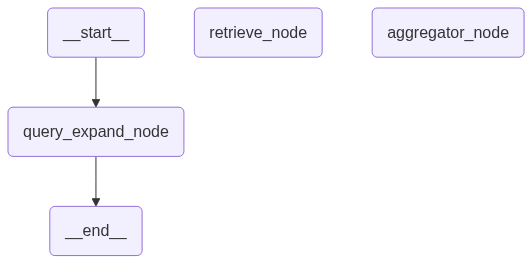

In [58]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [59]:
query = "Can I get a tablet for my kid, a watch for me and a laptop for my wife?"
initial_state = {
    "initial_query": query,
}

In [40]:
result = graph.invoke(initial_state)

AttributeError: 'dict' object has no attribute 'query'

In [60]:
result = graph.invoke(initial_state)

AttributeError: 'dict' object has no attribute 'query'

In [ ]:
result

In [ ]:
print(result["answer"])